# **EXPERIMENT-10**  -CustomerChurn Dataset

In [ ]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Step 2: Load dataset
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Datasets/Customer_Churn.csv')

print("Shape:", df.shape)
print("\nFirst 3 rows:\n", df.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (10000, 14)

First 3 rows:
    RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  


In [ ]:
# Step 3: Encode categorical variables
le = LabelEncoder()
for col in ['Geography', 'Gender']:
    df[col] = le.fit_transform(df[col])

# Step 4: Drop unnecessary columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Separate features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [ ]:
# Step 6: Base learner (Decision Stump)
base_model = DecisionTreeClassifier(max_depth=1, random_state=42)

# Step 7: AdaBoost Model
ada = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

ada.fit(X_train, y_train)


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   random_state=42)

In [ ]:

# Step 8: Predictions (Final Class Label)
y_pred = ada.predict(X_test)
print("\nFirst 10 Predicted Class Labels:\n", y_pred[:10])

# Step 9: Class Probabilities
y_prob = ada.predict_proba(X_test)
print("\nFirst 10 Predicted Class Probabilities:\n", y_prob[:10])



First 10 Predicted Class Labels:
 [0 0 0 0 0 0 0 0 1 0]

First 10 Predicted Class Probabilities:
 [[0.66809298 0.33190702]
 [0.656604   0.343396  ]
 [0.67823559 0.32176441]
 [0.67774633 0.32225367]
 [0.63535258 0.36464742]
 [0.61758023 0.38241977]
 [0.70115416 0.29884584]
 [0.54790004 0.45209996]
 [0.48938723 0.51061277]
 [0.63897739 0.36102261]]


In [ ]:

# Step 10: Weak Learner Weights and predictions
print("\nWeak Learner Weights (Alpha):")
print(ada.estimator_weights_)

for i, tree in enumerate(ada.estimators_[:3]):
    preds = tree.predict(X_test.values)
    print(f"Weak Learner {i+1} predictions (first 5 samples): {preds[:5]}")


Weak Learner Weights (Alpha):
[1.36301945 0.79364398 0.17903431 0.26544209 0.56447085 0.20064791
 0.29550955 0.25414508 0.43940936 0.20212318 0.20155717 0.17996811
 0.1620243  0.14684666 0.13382102 0.12250526 0.11257292 0.27627824
 0.29408912 0.26865357 0.20453326 0.23413446 0.14127855 0.06574565
 0.06934565 0.12349031 0.0846977  0.03185055 0.05139506 0.13858045
 0.13848631 0.07358005 0.04612482 0.04486474 0.04321029 0.13577089
 0.01416433 0.01882217 0.06471227 0.0600264  0.01754827 0.017239
 0.01709168 0.01694685 0.01680445 0.01738345 0.01722759 0.0166614
 0.0969018  0.11609286]
Weak Learner 1 predictions (first 5 samples): [0 0 0 0 0]
Weak Learner 2 predictions (first 5 samples): [0 0 0 0 0]
Weak Learner 3 predictions (first 5 samples): [1 1 1 1 1]


In [ ]:

# Step 11: Manual weighted sum
weighted_sum = np.zeros(len(X_test))
for alpha, tree in zip(ada.estimator_weights_, ada.estimators_):
    preds = tree.predict(X_test.values)
    preds_converted = np.where(preds == 0, -1, 1)
    weighted_sum += alpha * preds_converted

# Final decision from manual weighted sum
final_pred = np.where(weighted_sum > 0, 1, 0)
print("Manual weighted sum matches AdaBoost prediction:", np.all(final_pred == ada.predict(X_test)))

Manual weighted sum matches AdaBoost prediction: True


In [ ]:
# Step 12: Model Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.8535

Confusion Matrix:
 [[1513   80]
 [ 213  194]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.91      1593
           1       0.71      0.48      0.57       407

    accuracy                           0.85      2000
   macro avg       0.79      0.71      0.74      2000
weighted avg       0.84      0.85      0.84      2000



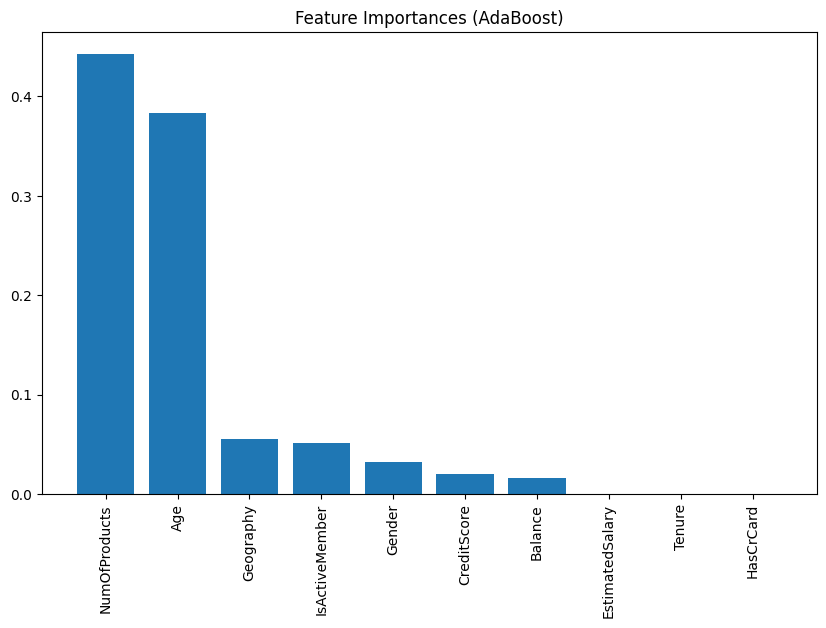

In [ ]:

# Step 13: Feature Importance
importances = ada.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.title("Feature Importances (AdaBoost)")
plt.show()